# cross_image — summary across all 8 stimuli

Reads each image's `entropies.npz`, builds:
- `results/cross_image_summary.png` — rows = images, cols = original |
  `H@L1` | `H@L6` | `H@L12` | `Σ|∇H| dL` | `Σ|∇²H| dL`. Color range
  fixed per row (so within-image comparisons are valid; across-image
  magnitudes can differ).
- `results/per_image_metrics.csv` — one row per (image, layer) with
  `H_mean, H_std, abs_grad_H_mean, abs_laplacian_H_mean, dH_mean, dH_std`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage
from PIL import Image

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
REPO = NB_DIR if (NB_DIR / "pyproject.toml").exists() else NB_DIR.parent
RESULTS = REPO / "results"
IMAGES = REPO / "images"
N_BLOCKS = 12

names = sorted(d.name for d in RESULTS.iterdir() if (d / "entropies.npz").exists())
print(f"images with entropies: {len(names)}")
print(f"  {names}")

images with entropies: 8
  ['cluttered', 'occlusion', 'single_object', 'symmetric', 'synth_checker', 'synth_gabor', 'synth_gradient', 'synth_texture_split']


In [2]:
H_per_image = {}
metrics_rows = []
for name in names:
    Hs = np.load(RESULTS / name / "entropies.npz")["H"]
    H_per_image[name] = Hs
    for L in range(N_BLOCKS):
        H = Hs[L]
        gy, gx = np.gradient(H)
        lap = scipy.ndimage.laplace(H)
        dH = (Hs[L] - Hs[L - 1]) if L > 0 else np.zeros_like(H)
        metrics_rows.append({
            "image": name, "layer": L + 1,
            "H_mean": float(H.mean()),
            "H_std": float(H.std()),
            "abs_grad_H_mean": float(np.hypot(gy, gx).mean()),
            "abs_laplacian_H_mean": float(np.abs(lap).mean()),
            "dH_mean": float(dH.mean()),
            "dH_std": float(dH.std()),
        })

metrics = pd.DataFrame(metrics_rows)
metrics.to_csv(RESULTS / "per_image_metrics.csv", index=False)
print(f"saved {RESULTS / 'per_image_metrics.csv'}  ({len(metrics)} rows)")
metrics.head(13)

saved /home/varun/research/eris/results/per_image_metrics.csv  (96 rows)


,image,layer,H_mean,H_std,abs_grad_H_mean,abs_laplacian_H_mean,dH_mean,dH_std
0,cluttered,1,1.433683,0.024080,0.020039,0.056439,0.000000,0.000000
1,cluttered,2,1.422507,0.020012,0.018381,0.049869,-0.011176,0.017650
2,cluttered,3,1.426344,0.016954,0.016264,0.040419,0.003837,0.013697
3,cluttered,4,1.431162,0.014194,0.012957,0.032457,0.004817,0.010492
4,cluttered,5,1.410287,0.125467,0.063502,0.195011,-0.020875,0.124022
5,cluttered,6,1.350136,0.360290,0.191518,0.582087,-0.060151,0.261534
6,cluttered,7,1.337477,0.406573,0.214726,0.653770,-0.012659,0.050787
7,cluttered,8,1.331018,0.418688,0.222105,0.671716,-0.006459,0.017189
8,cluttered,9,1.331529,0.420319,0.221895,0.673137,0.000511,0.011729
9,cluttered,10,1.332664,0.413338,0.218186,0.664527,0.001136,0.012656


## Cross-image grid

saved /home/varun/research/eris/results/cross_image_summary.png


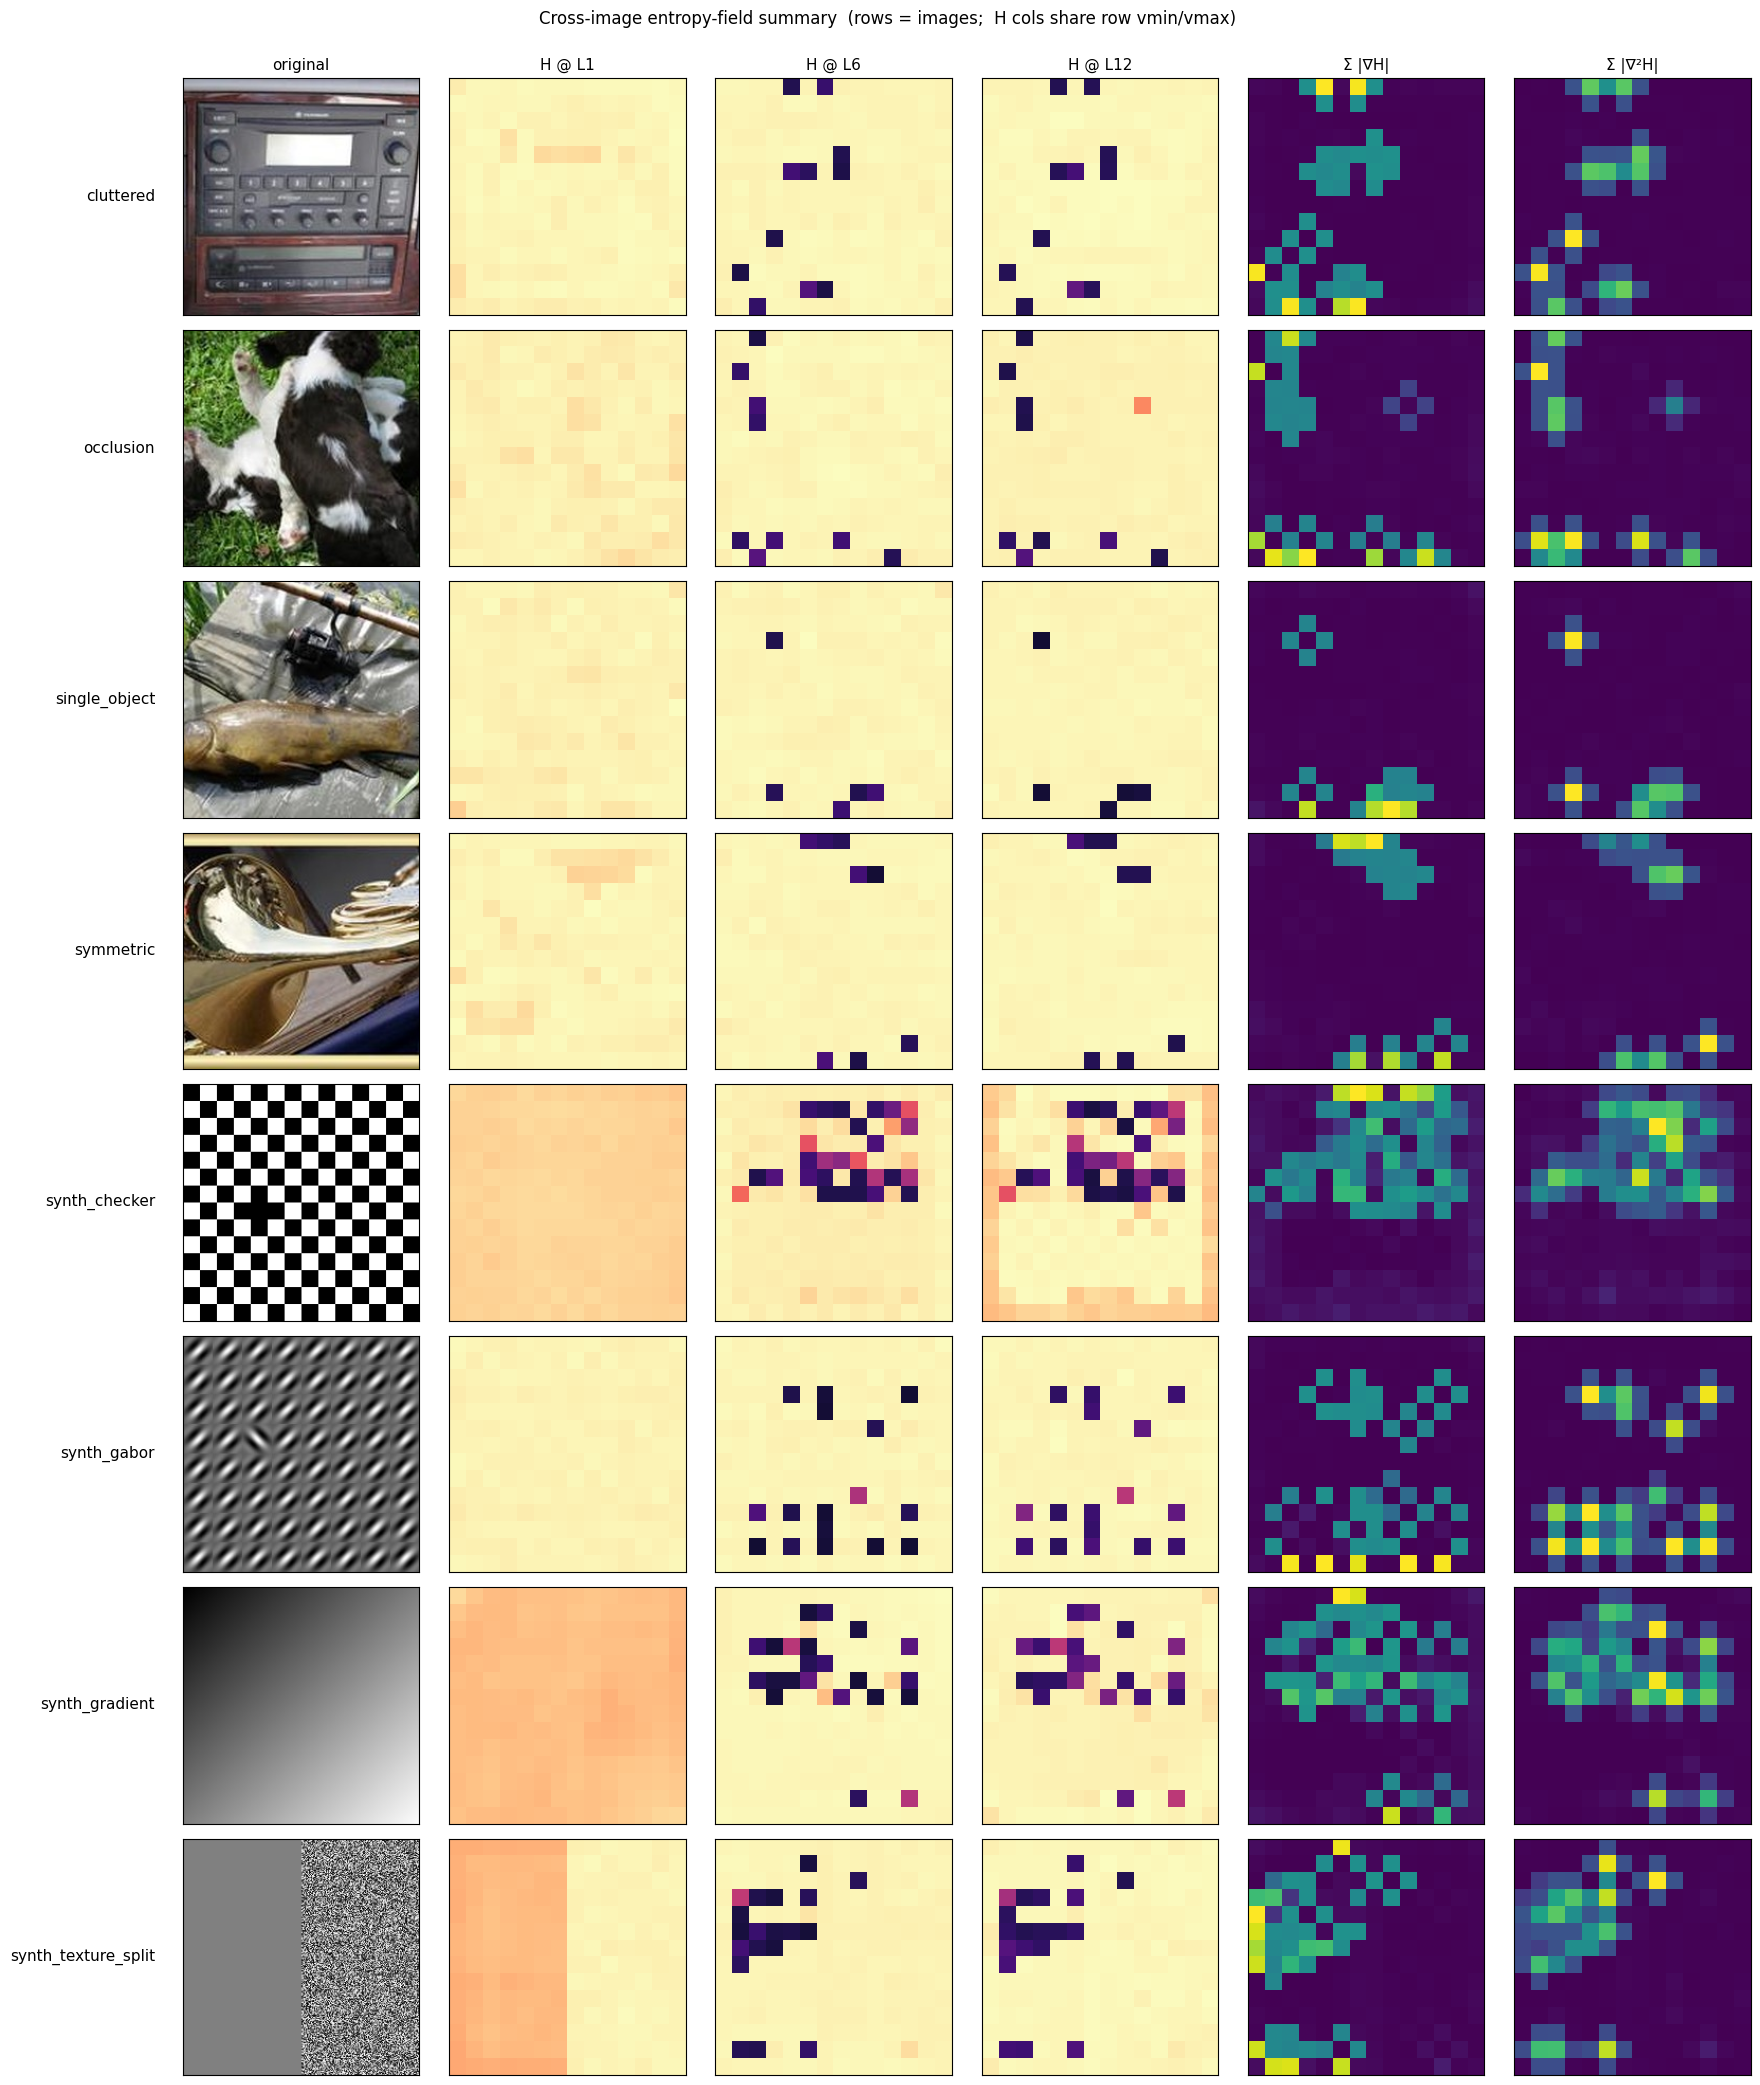

In [3]:
fig, axes = plt.subplots(len(names), 6, figsize=(18, 2.6 * len(names)))
for r, name in enumerate(names):
    Hs = H_per_image[name]
    img_pil = Image.open(IMAGES / f"{name}.jpg").convert("RGB")

    # Per-image fixed vmin/vmax for the H columns.
    vmin, vmax = float(Hs.min()), float(Hs.max())

    # Per-image cumulative gradient and laplacian magnitudes.
    grad_mag_sum = np.zeros_like(Hs[0])
    lap_abs_sum = np.zeros_like(Hs[0])
    for L in range(N_BLOCKS):
        gy, gx = np.gradient(Hs[L])
        grad_mag_sum += np.hypot(gy, gx)
        lap_abs_sum += np.abs(scipy.ndimage.laplace(Hs[L]))

    # Col 0: original image
    axes[r, 0].imshow(img_pil)
    axes[r, 0].set_ylabel(name, fontsize=11, rotation=0, ha="right",
                          va="center", labelpad=20)
    axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
    if r == 0: axes[r, 0].set_title("original", fontsize=11)

    # Col 1-3: H at L1, L6, L12
    for c, L in enumerate([0, 5, 11]):
        axes[r, 1 + c].imshow(Hs[L], vmin=vmin, vmax=vmax, cmap="magma")
        axes[r, 1 + c].set_xticks([]); axes[r, 1 + c].set_yticks([])
        if r == 0: axes[r, 1 + c].set_title(f"H @ L{L+1}", fontsize=11)

    # Col 4: cumulative gradient magnitude
    im = axes[r, 4].imshow(grad_mag_sum, cmap="viridis")
    axes[r, 4].set_xticks([]); axes[r, 4].set_yticks([])
    if r == 0: axes[r, 4].set_title("Σ |∇H|", fontsize=11)

    # Col 5: cumulative laplacian magnitude
    im = axes[r, 5].imshow(lap_abs_sum, cmap="viridis")
    axes[r, 5].set_xticks([]); axes[r, 5].set_yticks([])
    if r == 0: axes[r, 5].set_title("Σ |∇²H|", fontsize=11)

fig.suptitle("Cross-image entropy-field summary  (rows = images;  H cols share row vmin/vmax)",
             y=1.0)
fig.tight_layout()
fig.savefig(RESULTS / "cross_image_summary.png", dpi=180, bbox_inches="tight")
print(f"saved {RESULTS / 'cross_image_summary.png'}")

## Layer-wise statistics — paired with the input image strip

saved /home/varun/research/eris/results/depth_curves.png


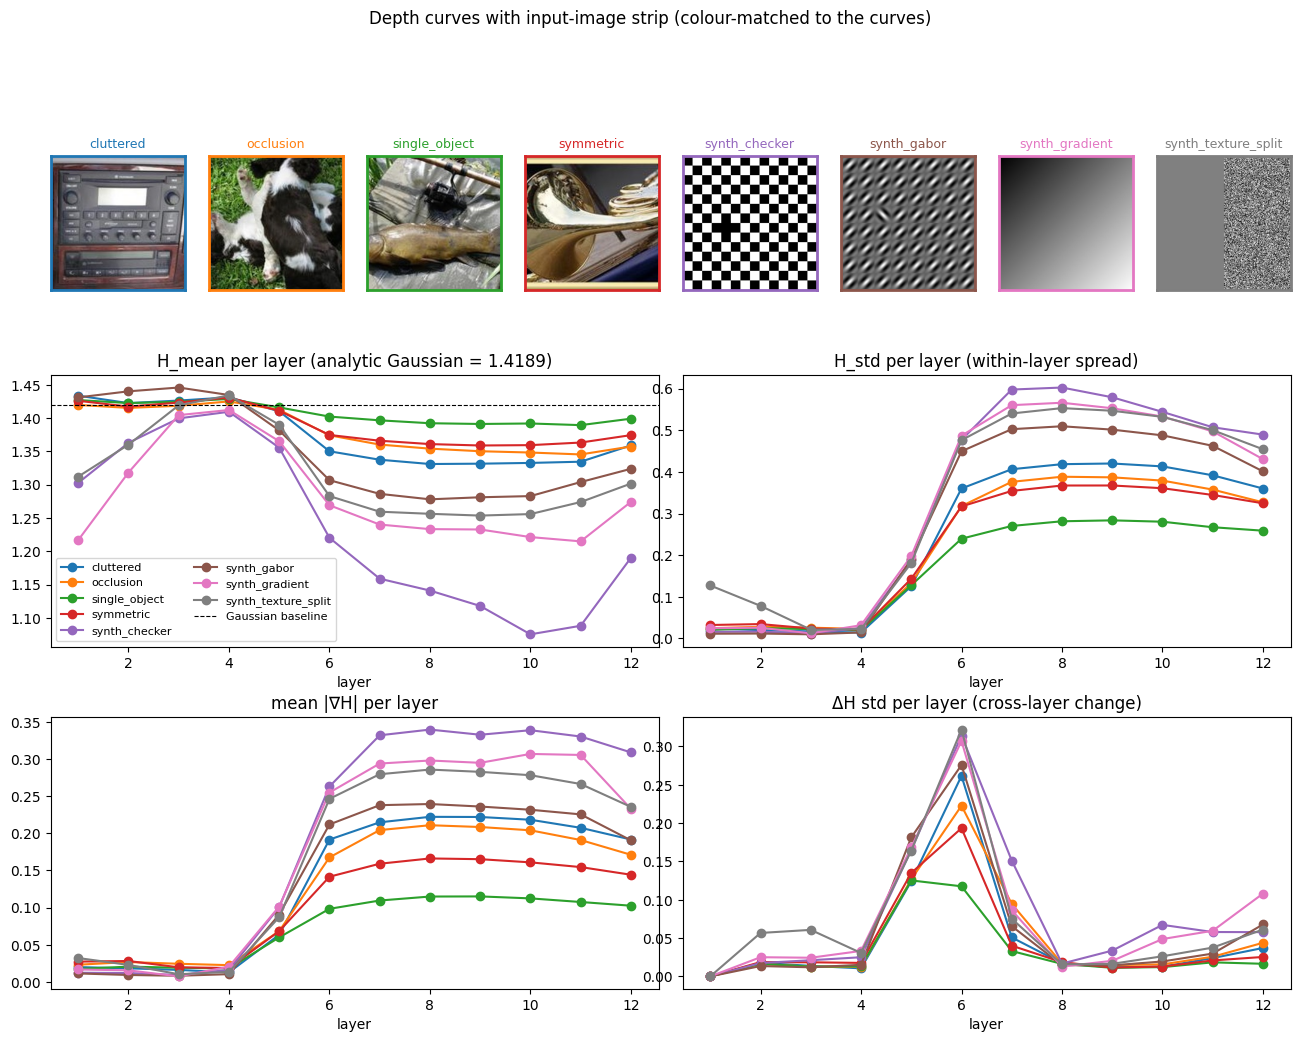

In [4]:
# Build a stable colour mapping image-name → colour. tab10 has 10 distinct
# entries; we have ≤8 images.
_tab10 = plt.get_cmap("tab10")
colors = {n: _tab10(i % 10) for i, n in enumerate(names)}

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(3, 4, height_ratios=[0.6, 1.0, 1.0], hspace=0.35,
                      wspace=0.25)

# Top strip: every input image, labelled, in the same colour as its curve.
for c, name in enumerate(names):
    ax = fig.add_subplot(gs[0, c % 4]) if c < 4 else None
# Actually: 8 images in a single row would be too narrow at this width.
# Use a separate strip subplot below.

# Re-do as 4 rows: image strip (1 row of 8 panels), then 2x2 metrics.
fig.clear()
gs = fig.add_gridspec(
    3, 8,
    height_ratios=[0.6, 1.0, 1.0],
    hspace=0.30, wspace=0.18,
)
for c, name in enumerate(names):
    ax = fig.add_subplot(gs[0, c])
    ax.imshow(Image.open(IMAGES / f"{name}.jpg").convert("RGB"))
    ax.set_title(name, fontsize=9, color=colors[name])
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(colors[name]); spine.set_linewidth(2.0)

ax_mean = fig.add_subplot(gs[1, :4])
ax_std = fig.add_subplot(gs[1, 4:])
ax_grad = fig.add_subplot(gs[2, :4])
ax_dH = fig.add_subplot(gs[2, 4:])

for name in names:
    sub = metrics[metrics["image"] == name].sort_values("layer")
    c = colors[name]
    ax_mean.plot(sub["layer"], sub["H_mean"], marker="o", color=c, label=name)
    ax_std.plot(sub["layer"], sub["H_std"], marker="o", color=c, label=name)
    ax_grad.plot(sub["layer"], sub["abs_grad_H_mean"], marker="o", color=c, label=name)
    ax_dH.plot(sub["layer"], sub["dH_std"], marker="o", color=c, label=name)

ax_mean.set_title("H_mean per layer (analytic Gaussian = 1.4189)")
ax_mean.axhline(0.5 * np.log(2 * np.pi * np.e), color="k", lw=0.8, ls="--",
                label="Gaussian baseline")
ax_std.set_title("H_std per layer (within-layer spread)")
ax_grad.set_title("mean |∇H| per layer")
ax_dH.set_title("ΔH std per layer (cross-layer change)")
for ax in (ax_mean, ax_std, ax_grad, ax_dH):
    ax.set_xlabel("layer")
ax_mean.legend(fontsize=8, loc="lower left", ncol=2)
fig.suptitle("Depth curves with input-image strip (colour-matched to the curves)",
             y=1.0)
fig.savefig(RESULTS / "depth_curves.png", dpi=160, bbox_inches="tight")
print(f"saved {RESULTS / 'depth_curves.png'}")